In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet("../data/churn_frame.parquet")

def add_features(df):
    df = df.copy()
    df["engagement_rate"]   = (df["active_days"] / 30.0).clip(0, 1)
    df["usage_per_login"]   = df["monthly_usage_hours"] / (df["login_count"] + 1e-3)
    df["support_intensity"] = df["support_tickets"] + 3 * df["sla_breaches"]
    df["email_ctr"]         = df["email_clicks"] / (df["email_opens"] + 1e-3)
    df["price_to_tenure"]   = df["billing_amount"] / (df["tenure_months"] + 1e-3)
    return df

df = add_features(df)

# Reference = training data, "production" = val data with simulated drift
split_idx = int(len(df) * 0.80)
ref_df   = df.iloc[:split_idx]
prod_df  = df.iloc[split_idx:].copy()

# Simulate drift: reduce engagement_rate in prod (behavioral shift)
prod_df["engagement_rate"] = prod_df["engagement_rate"] * 0.70

print(f"Reference distribution mean engagement_rate: {ref_df['engagement_rate'].mean():.3f}")
print(f"Production distribution mean engagement_rate: {prod_df['engagement_rate'].mean():.3f}")
print(f"\n⚠️  Drift simulated: engagement_rate dropped 30%")

Reference distribution mean engagement_rate: 0.650
Production distribution mean engagement_rate: 0.452

⚠️  Drift simulated: engagement_rate dropped 30%


In [2]:
def compute_psi(ref: pd.Series, prod: pd.Series, bins=10) -> float:
    """
    Population Stability Index (PSI).
    
    PSI < 0.10  → No significant change
    PSI 0.10-0.25 → Moderate change, monitor
    PSI > 0.25  → Significant shift, retrain
    """
    ref_np  = ref.dropna().values
    prod_np = prod.dropna().values
    
    breakpoints = np.percentile(ref_np, np.linspace(0, 100, bins + 1))
    breakpoints[0]  -= 1e-6
    breakpoints[-1] += 1e-6
    
    ref_counts  = np.histogram(ref_np,  bins=breakpoints)[0]
    prod_counts = np.histogram(prod_np, bins=breakpoints)[0]
    
    ref_pct  = ref_counts  / len(ref_np)  + 1e-8
    prod_pct = prod_counts / len(prod_np) + 1e-8
    
    psi = np.sum((prod_pct - ref_pct) * np.log(prod_pct / ref_pct))
    return psi

# Monitor key features
monitor_feats = [
    "engagement_rate", "support_intensity", "tenure_months",
    "nps_score", "billing_amount", "price_to_tenure"
]

print("=== PSI Drift Report ===\n")
print(f"{'Feature':<30} {'PSI':>8}  {'Status'}")
print("-" * 55)
for feat in monitor_feats:
    psi = compute_psi(ref_df[feat], prod_df[feat])
    if psi < 0.10:
        status = "✅ Stable"
    elif psi < 0.25:
        status = "⚠️  Monitor"
    else:
        status = "🚨 RETRAIN"
    print(f"  {feat:<28} {psi:>8.4f}  {status}")

=== PSI Drift Report ===

Feature                             PSI  Status
-------------------------------------------------------
  engagement_rate               13.3979  🚨 RETRAIN
  support_intensity              0.0039  ✅ Stable
  tenure_months                  0.0060  ✅ Stable
  nps_score                      0.0049  ✅ Stable
  billing_amount                 0.0031  ✅ Stable
  price_to_tenure                0.0071  ✅ Stable


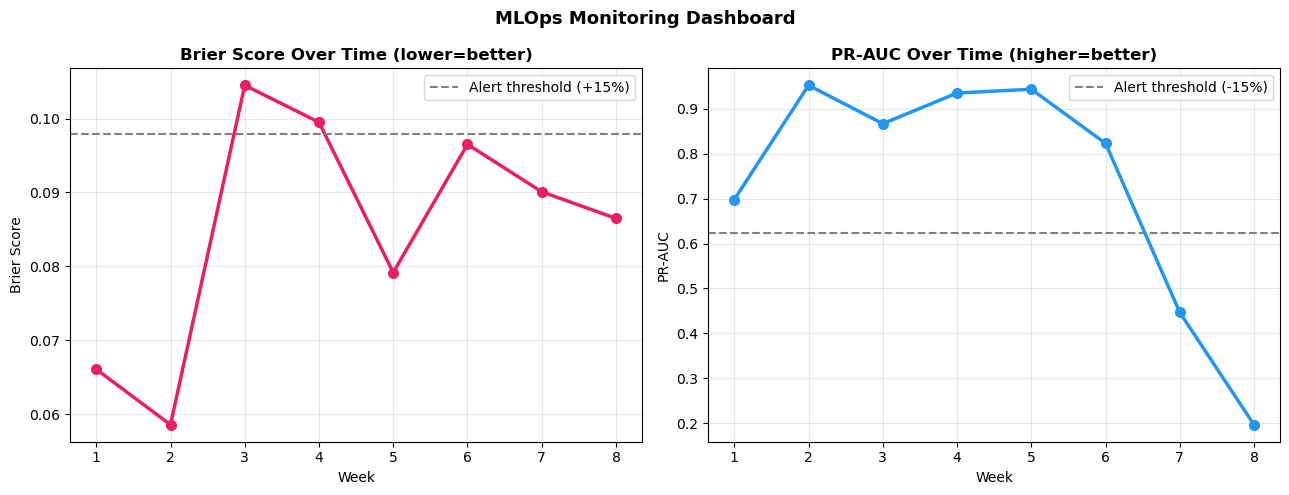

Saved → ../data/mlops_monitoring.png


In [3]:
from sklearn.metrics import brier_score_loss, average_precision_score

model = joblib.load("../models/churn_calibrated.joblib")
TARGET  = "churned_next_cycle"
EXCLUDE = [TARGET, "cycle_start", "cycle_end", "customer_id"]

# Simulate weekly cohorts
prod_with_outcome = df.iloc[split_idx:].copy()
prod_with_outcome = prod_with_outcome.sort_values("cycle_start").reset_index(drop=True)

weekly_chunks = np.array_split(prod_with_outcome, 8)
weeks, briers, pr_aucs = [], [], []

for i, chunk in enumerate(weekly_chunks):
    if len(chunk) < 20:
        continue
    X_c = chunk.drop(columns=EXCLUDE)
    y_c = chunk[TARGET]
    proba_c = model.predict_proba(X_c)[:, 1]
    weeks.append(i + 1)
    briers.append(brier_score_loss(y_c, proba_c))
    pr_aucs.append(average_precision_score(y_c, proba_c))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("MLOps Monitoring Dashboard", fontsize=13, fontweight='bold')

ax1.plot(weeks, briers, "o-", color="#E91E63", lw=2.5, ms=7)
ax1.axhline(y=np.mean(briers)*1.15, color='gray', ls='--', label="Alert threshold (+15%)")
ax1.set_title("Brier Score Over Time (lower=better)", fontweight='bold')
ax1.set_xlabel("Week"); ax1.set_ylabel("Brier Score"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(weeks, pr_aucs, "o-", color="#2196F3", lw=2.5, ms=7)
ax2.axhline(y=np.mean(pr_aucs)*0.85, color='gray', ls='--', label="Alert threshold (-15%)")
ax2.set_title("PR-AUC Over Time (higher=better)", fontweight='bold')
ax2.set_xlabel("Week"); ax2.set_ylabel("PR-AUC"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../data/mlops_monitoring.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved → ../data/mlops_monitoring.png")

In [4]:
# This is the production batch scoring logic (run daily)
# In production: run as cron job / Airflow DAG

def batch_score(input_path: str, output_path: str, model_path: str) -> pd.DataFrame:
    """
    Load new customer data, score, and export results for CRM.
    """
    model = joblib.load(model_path)
    df    = pd.read_parquet(input_path)
    df    = add_features(df)
    
    EXCLUDE_COLS = ["churned_next_cycle", "cycle_start", "cycle_end", "customer_id"]
    X = df.drop(columns=[c for c in EXCLUDE_COLS if c in df.columns])
    
    proba = model.predict_proba(X)[:, 1]
    
    df["churn_prob"]   = proba
    df["risk_tier"]    = pd.cut(proba, bins=[0,0.25,0.50,1.0],
                                labels=["Low","Medium","High"])
    df["scored_at"]    = pd.Timestamp.now().isoformat()
    
    results = df[["customer_id","churn_prob","risk_tier","scored_at"]]
    results.to_parquet(output_path, index=False)
    return results

print("✅ batch_score() function defined")
print("\nUsage:")
print("  results = batch_score(")
print("      input_path='data/new_customers.parquet',")
print("      output_path='data/churn_scores_today.parquet',")
print("      model_path='models/churn_calibrated.joblib'")
print("  )")

✅ batch_score() function defined

Usage:
  results = batch_score(
      input_path='data/new_customers.parquet',
      output_path='data/churn_scores_today.parquet',
      model_path='models/churn_calibrated.joblib'
  )


In [5]:
architecture = """
┌─────────────────────────────────────────────────────────┐
│              Customer Churn MLOps Architecture           │
├─────────────────────────────────────────────────────────┤
│                                                         │
│  DATA LAYER          TRAINING          SERVING          │
│  ──────────          ────────          ───────          │
│  CSV/Parquet    →    XGBoost +    →    FastAPI          │
│  (billing,           Optuna +         /score           │
│   usage,             Calibration      /explain         │
│   support)                ↓                ↓           │
│                     models/          churn_scores      │
│                     *.joblib         .parquet → CRM    │
│                                                         │
│  MONITORING                                             │
│  ──────────                                             │
│  • PSI on key features (weekly)                         │
│  • Brier score trend (weekly)                           │
│  • PR-AUC on realized outcomes (weekly)                 │
│  • Retrain trigger: PSI > 0.25 or PR-AUC drop > 15%   │
│                                                         │
│  GOVERNANCE                                             │
│  ──────────                                             │
│  • Model versioned with training data hash              │
│  • Predictions logged with anonymized IDs               │
│  • Opt-out flag respected in scoring pipeline           │
└─────────────────────────────────────────────────────────┘
"""
print(architecture)


┌─────────────────────────────────────────────────────────┐
│              Customer Churn MLOps Architecture           │
├─────────────────────────────────────────────────────────┤
│                                                         │
│  DATA LAYER          TRAINING          SERVING          │
│  ──────────          ────────          ───────          │
│  CSV/Parquet    →    XGBoost +    →    FastAPI          │
│  (billing,           Optuna +         /score           │
│   usage,             Calibration      /explain         │
│   support)                ↓                ↓           │
│                     models/          churn_scores      │
│                     *.joblib         .parquet → CRM    │
│                                                         │
│  MONITORING                                             │
│  ──────────                                             │
│  • PSI on key features (weekly)                         │
│  • Brier score trend (weekly)            